# Create Water Level Elevation Map

This notebook creates an elevation map by overlaying water surface polygons from different time steps, colored by their corresponding gage height (elevation).

In [95]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import Normalize
from matplotlib import cm
from PIL import Image
import cv2
from skimage import measure

## Existing Runs

Runs with an existing `run_config.json`:

In [96]:
import glob
for cfg in sorted(glob.glob('cameras/*/*/run_config.json')):
    parts = cfg.split(os.sep)
    print(f"camera_id = '{parts[1]}'")
    print(f"run_name  = '{parts[2]}'")
    print()

camera_id = 'CA_Arroyo_DE_LA_Laguna_A_Corte_Madrid_nr_Pleasanton'
run_name  = 'event_2026-02-15'

camera_id = 'OK_Illinois_River_near_Moodys'
run_name  = 'event_2026-03-04'

camera_id = 'SC_Waccamaw_River_at_SC_22_below_Longs'
run_name  = 'event_2025-08-14'

camera_id = 'VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX'
run_name  = 'event_2026-03-16'

camera_id = 'WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet'
run_name  = 'event_2025-06-23'



## Configuration

In [97]:
# Camera and directory configuration
camera_id = 'WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet'
run_name  = 'event_2025-06-23'
run_dir = f'cameras/{camera_id}/{run_name}'

images_dir = f'{run_dir}/images'
masks_dir = f'{run_dir}/masks'
csv_path = f'{run_dir}/images_and_data.csv'

# Output directory for elevation map
output_dir = f'{run_dir}/elevation_maps'
os.makedirs(output_dir, exist_ok=True)

print(f"Loading data from: {csv_path}")
print(f"Output will be saved to: {output_dir}")

Loading data from: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/event_2025-06-23/images_and_data.csv
Output will be saved to: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/event_2025-06-23/elevation_maps


## Load Images and Data

In [98]:
# Load the CSV with images, masks, and gage height data
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} records")

# Filter out bad quality masks if quality_flag column exists
if 'quality_flag' in df.columns:
    n_bad = (df['quality_flag'] == 'bad').sum()
    if n_bad > 0:
        print(f"\nFound {n_bad} masks marked as 'bad' - excluding from analysis")
        bad_indices = df[df['quality_flag'] == 'bad'].index.tolist()
        print(f"Excluded indices: {bad_indices}")
        df = df[df['quality_flag'] != 'bad'].reset_index(drop=True)
        print(f"Remaining records after filtering: {len(df)}")
    else:
        print(f"\nAll masks marked as 'good' - no filtering applied")
else:
    print(f"\nNo quality_flag column found - using all masks")
    print(f"(Run notebook 02.5 to review and flag bad masks)")

print(f"\nColumns: {df.columns.tolist()}")
print(f"\nGage height (00065) range: {df['00065'].min():.2f} to {df['00065'].max():.2f} ft")
print(f"\nFirst few rows:")
display(df[['image_names', 'mask_filename', '00065']].head())

Loaded 62 records

Found 7 masks marked as 'bad' - excluding from analysis
Excluded indices: [3, 4, 28, 29, 31, 32, 33]
Remaining records after filtering: 55

Columns: ['Unnamed: 0', 'image_times', 'image_names', 'data_times', 'site_no', '00060', '00060_cd', '00065', '00065_cd', '63160', '63160_cd', 'time_diff_sec', 'mask_filename', 'quality_flag']

Gage height (00065) range: 4.60 to 10.91 ft

First few rows:


,image_names,mask_filename,00065
0,WI_East_Branch_Pecatonica_River_near_Blanchard...,00000_obj1.npy,4.60
1,WI_East_Branch_Pecatonica_River_near_Blanchard...,00001_obj1.npy,4.60
2,WI_East_Branch_Pecatonica_River_near_Blanchard...,00002_obj1.npy,4.60
3,WI_East_Branch_Pecatonica_River_near_Blanchard...,00005_obj1.npy,5.75
4,WI_East_Branch_Pecatonica_River_near_Blanchard...,00006_obj1.npy,5.83


## Helper Functions

In [99]:
def mask_to_polygons(mask, simplify_tolerance=2.0):
    """
    Convert a binary mask to polygon contours.
    
    Args:
        mask: Binary mask array (boolean or 0/1)
        simplify_tolerance: Tolerance for polygon simplification (higher = simpler)
    
    Returns:
        List of polygons, each as an array of (x, y) coordinates
    """
    # Ensure mask is boolean
    if mask.ndim == 3:
        mask = mask.squeeze()
    mask_bool = mask.astype(bool)
    
    # Find contours using OpenCV
    mask_uint8 = (mask_bool * 255).astype(np.uint8)
    contours, hierarchy = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    polygons = []
    for contour in contours:
        # Simplify contour to reduce number of points
        epsilon = simplify_tolerance
        approx = cv2.approxPolyDP(contour, epsilon, True)
        
        # Convert to (x, y) coordinates
        if len(approx) >= 3:  # Need at least 3 points for a polygon
            poly = approx.squeeze()
            if poly.ndim == 2:  # Valid polygon
                polygons.append(poly)
    
    return polygons


def load_mask(mask_path):
    """
    Load a mask from a .npy file.
    
    Args:
        mask_path: Path to .npy mask file
    
    Returns:
        Binary mask array
    """
    mask = np.load(mask_path)
    if mask.ndim == 3:
        mask = mask.squeeze()
    return mask.astype(bool)

## Extract Polygons from All Masks

Convert each water mask to polygon(s) and associate with elevation data.

In [100]:
# Store all polygons with their elevations
polygon_data = []

print("Extracting polygons from masks...")
for idx, row in df.iterrows():
    mask_filename = row['mask_filename']
    mask_path = os.path.join(masks_dir, mask_filename)
    
    if not os.path.exists(mask_path):
        print(f"Warning: Mask not found: {mask_path}")
        continue
    
    # Load mask and convert to polygons
    mask = load_mask(mask_path)
    polygons = mask_to_polygons(mask, simplify_tolerance=2.0)
    
    # Get elevation (gage height) for this mask
    elevation = row['00065']
    # discharge = row['00060']
    image_name = row['image_names']
    
    # Store each polygon with its metadata
    for poly in polygons:
        polygon_data.append({
            'polygon': poly,
            'elevation': elevation,
            # 'discharge': discharge,
            'image_name': image_name,
            'mask_filename': mask_filename
        })

sorted_polygon_data_by_elevation = sorted(polygon_data, key=lambda x: x['elevation'], reverse=True)

print(f"\nExtracted {len(polygon_data)} polygons from {len(df)} masks")
print(f"Elevation range: {min(p['elevation'] for p in polygon_data):.2f} to {max(p['elevation'] for p in polygon_data):.2f} ft")

Extracting polygons from masks...

Extracted 86 polygons from 55 masks
Elevation range: 4.60 to 10.91 ft


## Create Elevation Map Visualization

Overlay all water surface polygons on a single plot, colored by their gage height.

In [101]:
# Load a reference image to get dimensions and for background
reference_image_path = os.path.join(images_dir, df.iloc[0]['image_names'])
reference_image = Image.open(reference_image_path)
img_width, img_height = reference_image.size

print(f"Reference image size: {img_width} x {img_height}")
print(f"Using image: {df.iloc[0]['image_names']}")

Reference image size: 1920 x 1080
Using image: WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet___2025-06-23T23-00-02Z.jpg


C:\Users\igsarmew-agis\AppData\Local\Temp\2\ipykernel_17168\2040213953.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')  # Can use 'viridis', 'plasma', 'coolwarm', 'RdYlBu_r', etc.



Saved elevation map to: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/event_2025-06-23/elevation_maps\elevation_map_with_background.png


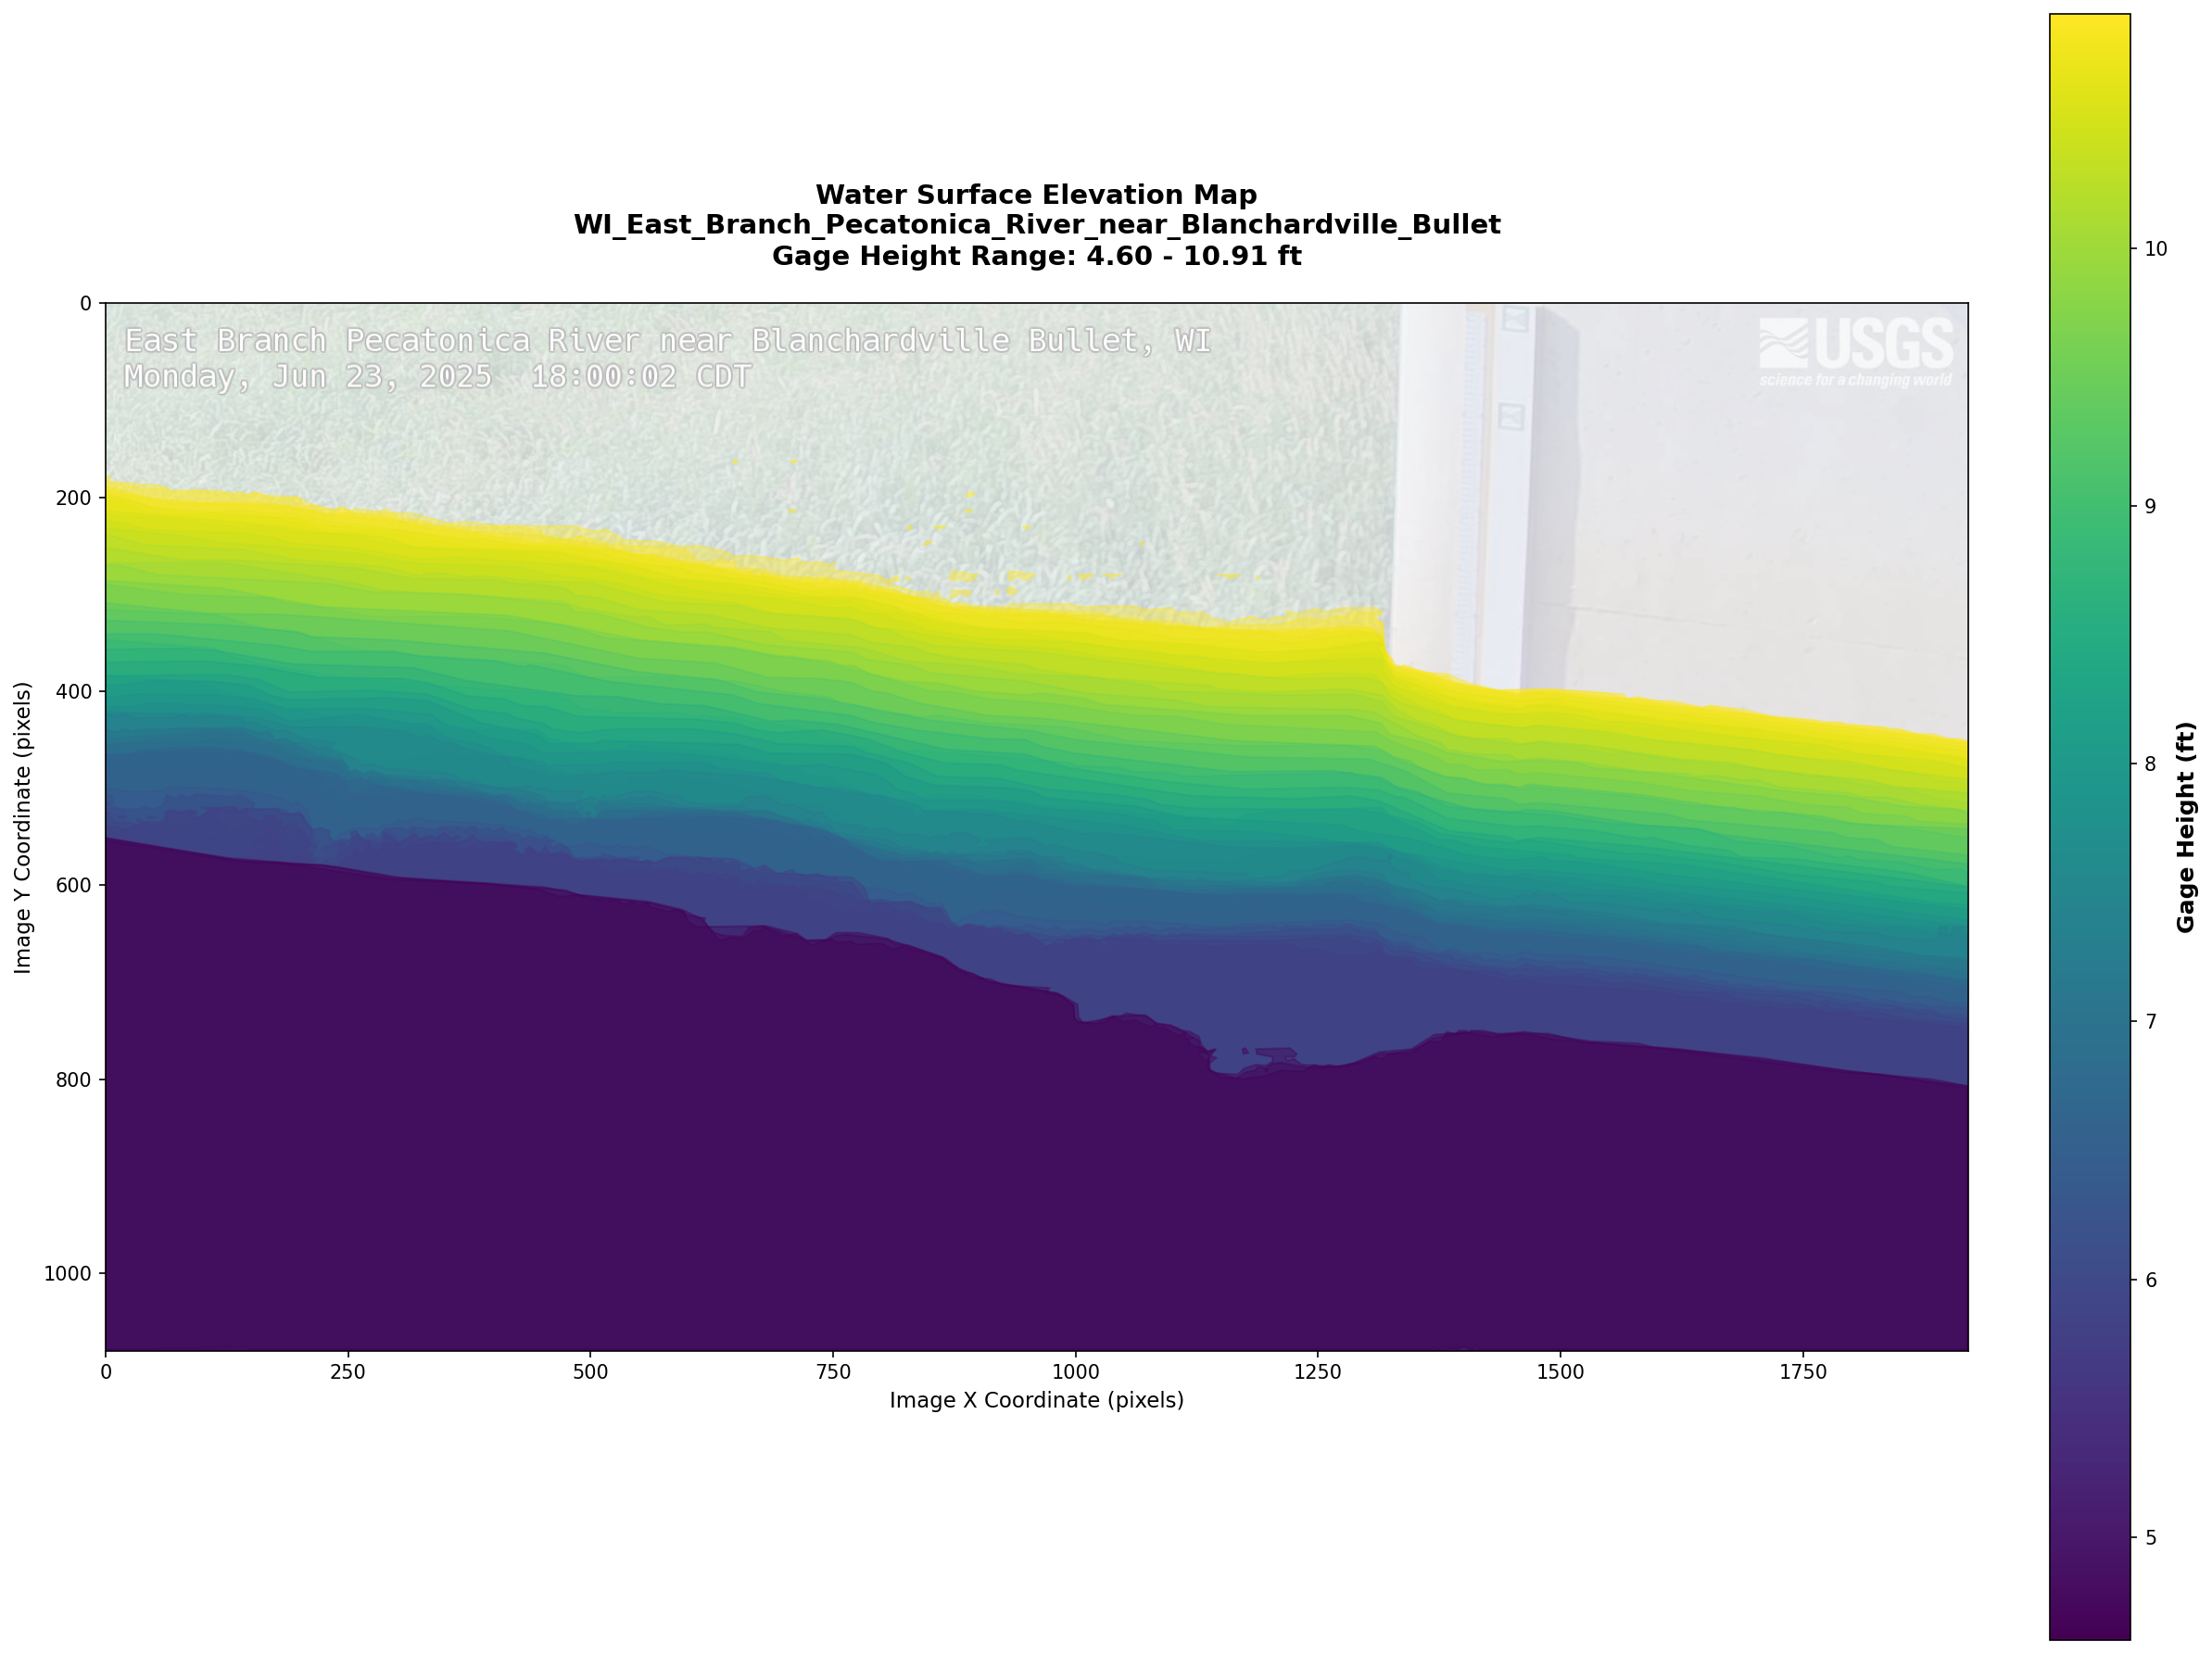

In [102]:
# Create the elevation map figure
fig, ax = plt.subplots(figsize=(16, 12), dpi=150)

# Show the reference image as background (optional - can be removed for cleaner view)
ax.imshow(reference_image, alpha=0.3)

# Prepare colormap
elevations = [p['elevation'] for p in polygon_data]
min_elevation = min(elevations)
max_elevation = max(elevations)

norm = Normalize(vmin=min_elevation, vmax=max_elevation)
cmap = cm.get_cmap('viridis')  # Can use 'viridis', 'plasma', 'coolwarm', 'RdYlBu_r', etc.

# Plot each polygon
for poly_data in sorted_polygon_data_by_elevation:
    poly = poly_data['polygon']
    elevation = poly_data['elevation']
    
    # Get color for this elevation
    color = cmap(norm(elevation))
    
    # Draw filled polygon with some transparency
    ax.fill(poly[:, 0], poly[:, 1], color=color, alpha=0.4, edgecolor=color, linewidth=1)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Gage Height (ft)', fontsize=12, weight='bold')

# Set labels and title
ax.set_xlabel('Image X Coordinate (pixels)', fontsize=11)
ax.set_ylabel('Image Y Coordinate (pixels)', fontsize=11)
ax.set_title(f'Water Surface Elevation Map\n{camera_id}\nGage Height Range: {min_elevation:.2f} - {max_elevation:.2f} ft',
             fontsize=14, weight='bold', pad=20)

# Set axis limits
ax.set_xlim(0, img_width)
ax.set_ylim(img_height, 0)  # Invert y-axis to match image coordinates

plt.tight_layout()

# Save the figure
output_path = os.path.join(output_dir, 'elevation_map_with_background.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"\nSaved elevation map to: {output_path}")

plt.show()

## Create Clean Elevation Map (No Background Image)


Saved clean elevation map to: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/event_2025-06-23/elevation_maps\elevation_map_clean.png


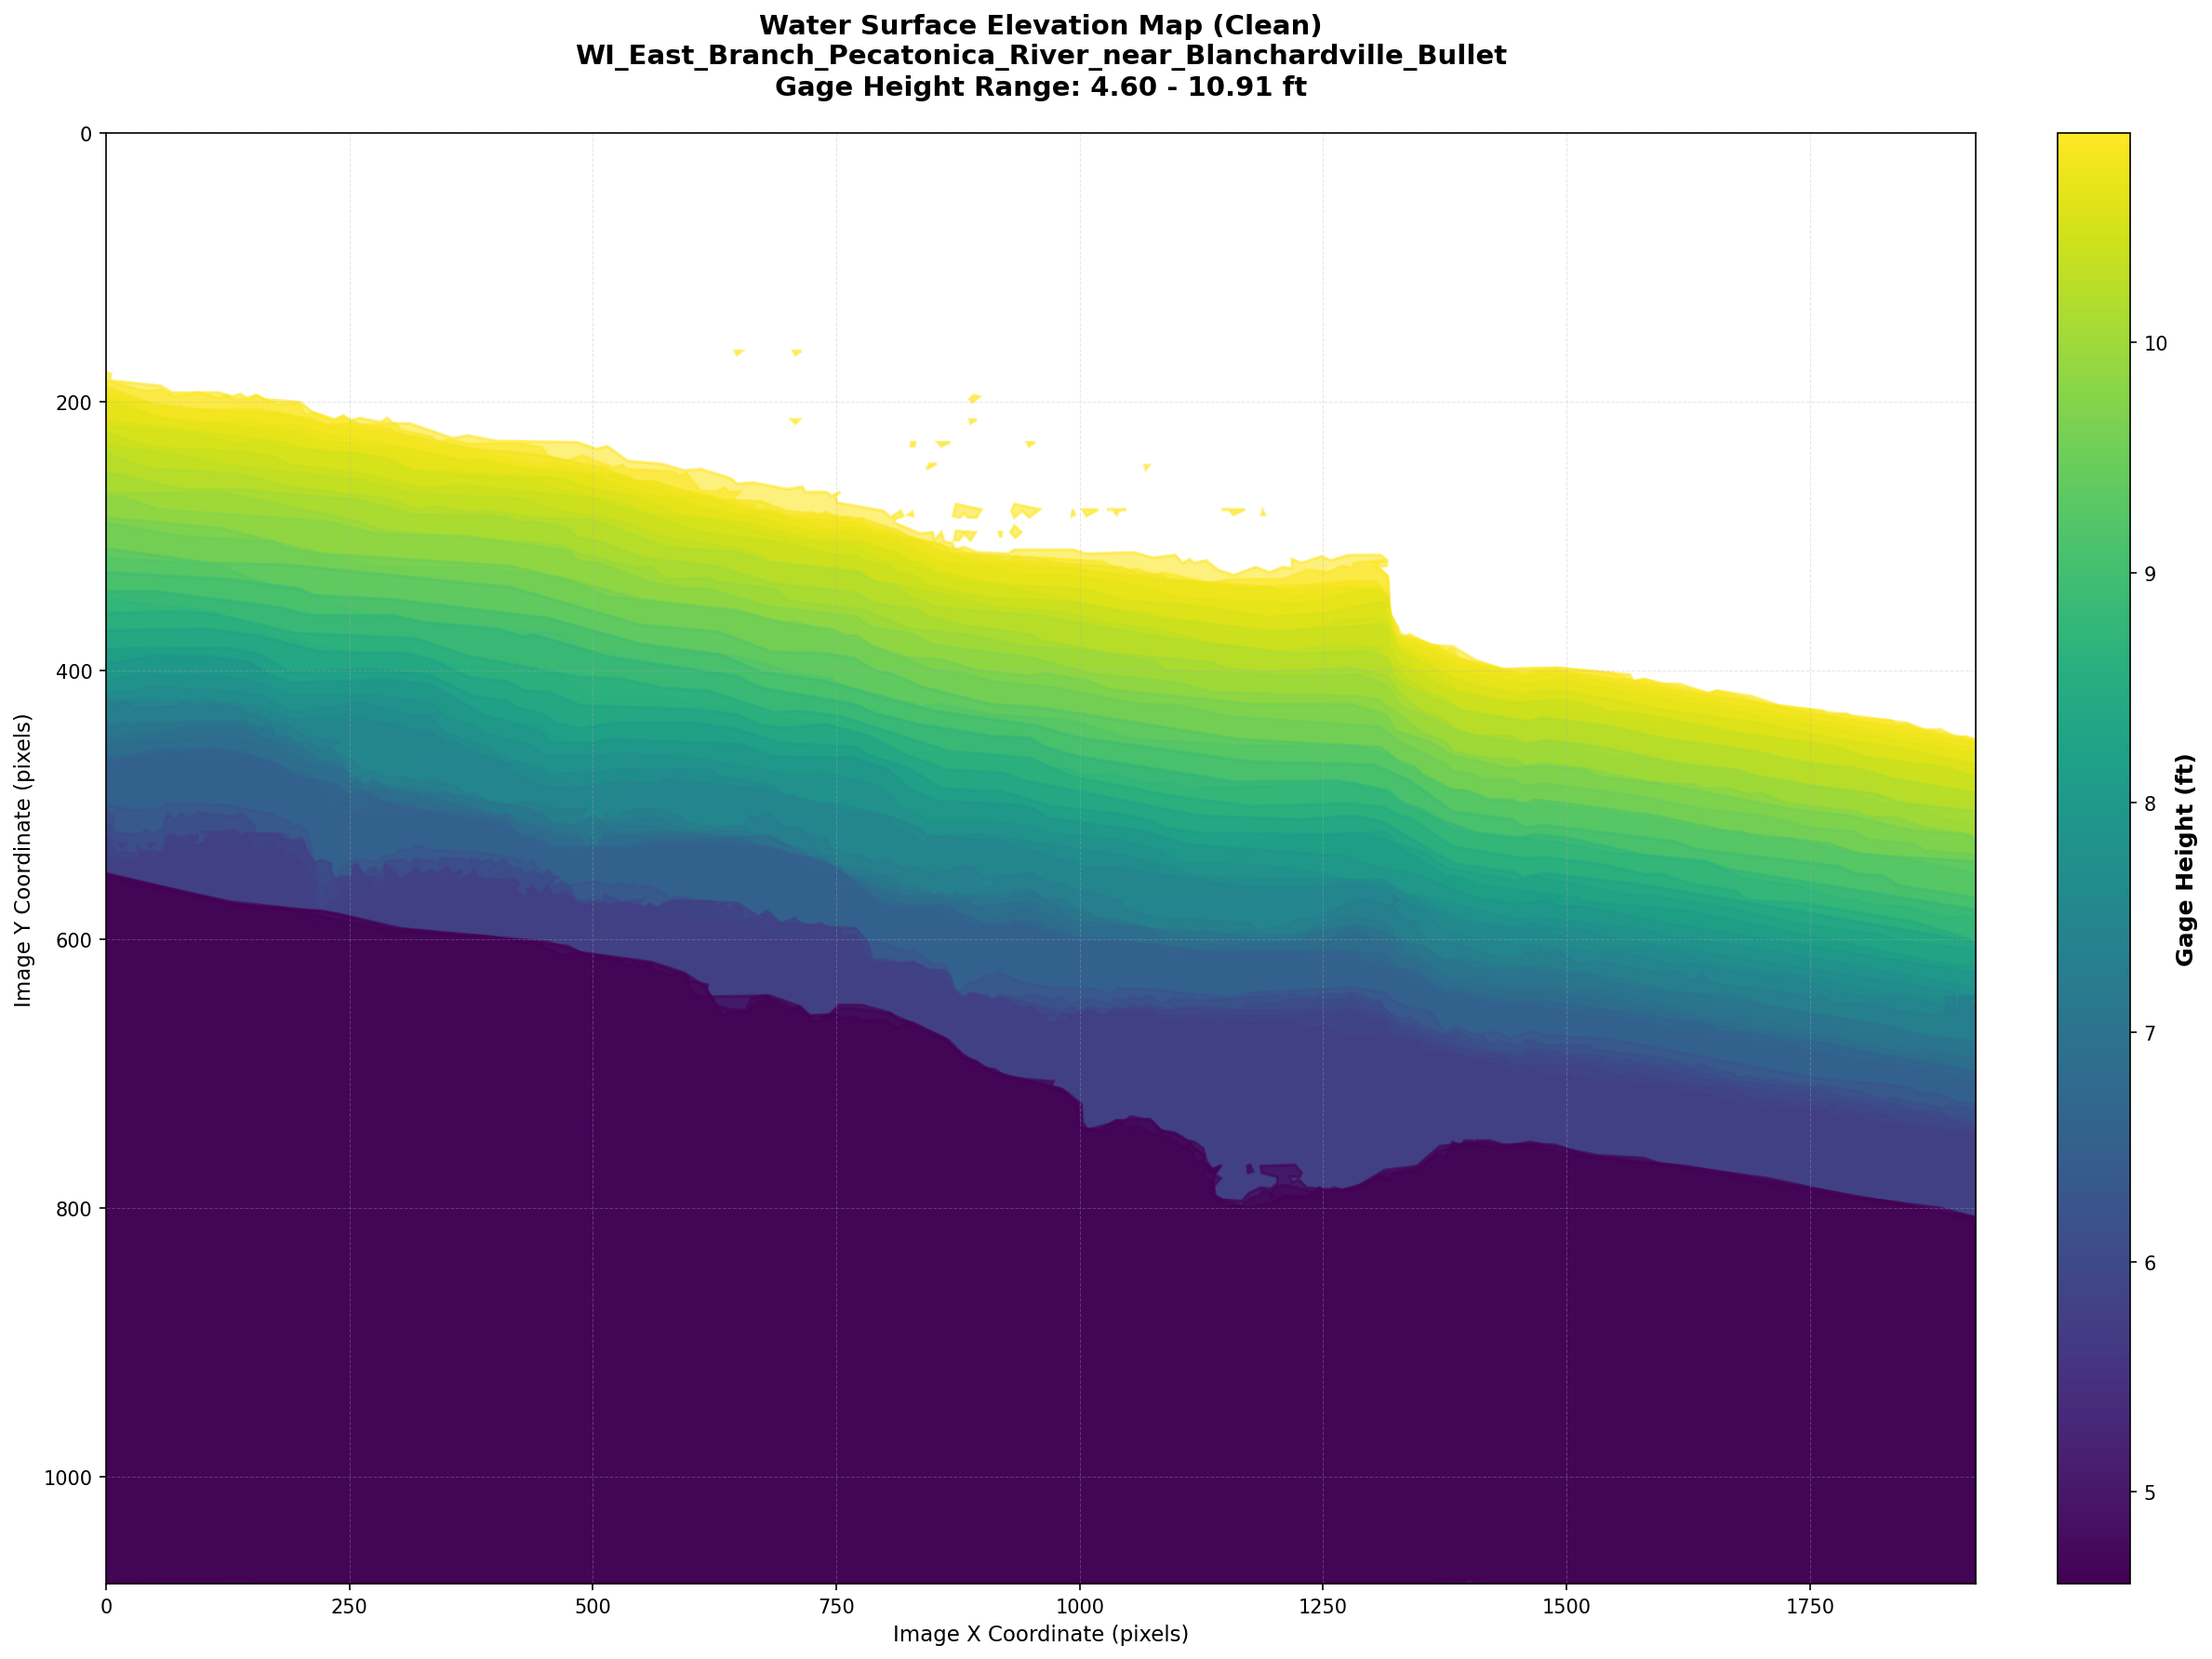

In [103]:
# Create elevation map without background image for cleaner visualization
fig, ax = plt.subplots(figsize=(16, 12), dpi=150)

# White background
ax.set_facecolor('white')

# Plot each polygon
for poly_data in sorted_polygon_data_by_elevation:
    poly = poly_data['polygon']
    elevation = poly_data['elevation']
    
    # Get color for this elevation
    color = cmap(norm(elevation))
    
    # Draw filled polygon
    ax.fill(poly[:, 0], poly[:, 1], color=color, alpha=0.6, edgecolor=color, linewidth=1.5)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Gage Height (ft)', fontsize=12, weight='bold')

# Set labels and title
ax.set_xlabel('Image X Coordinate (pixels)', fontsize=11)
ax.set_ylabel('Image Y Coordinate (pixels)', fontsize=11)
ax.set_title(f'Water Surface Elevation Map (Clean)\n{camera_id}\nGage Height Range: {min_elevation:.2f} - {max_elevation:.2f} ft',
             fontsize=14, weight='bold', pad=20)

# Set axis limits
ax.set_xlim(0, img_width)
ax.set_ylim(img_height, 0)  # Invert y-axis to match image coordinates
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()

# Save the figure
output_path = os.path.join(output_dir, 'elevation_map_clean.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"\nSaved clean elevation map to: {output_path}")

plt.show()

## Elevation Statistics and Analysis


ELEVATION MAP STATISTICS


,Metric,Value
0,Minimum Gage Height,4.60 ft
1,Maximum Gage Height,10.91 ft
2,Elevation Range,6.31 ft
3,Mean Gage Height,8.59 ft
4,Median Gage Height,8.84 ft
5,Number of Time Steps,55
6,Total Polygons,86



Saved statistics plots to: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/event_2025-06-23/elevation_maps\elevation_statistics.png


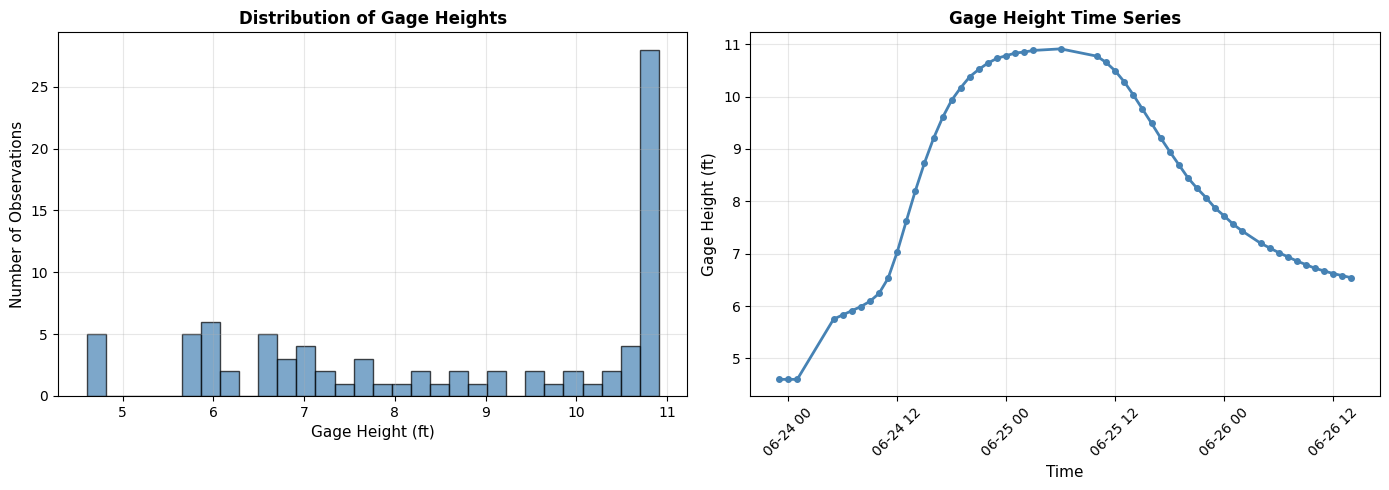

In [104]:
# Calculate statistics
elevation_stats = pd.DataFrame([
    {'Metric': 'Minimum Gage Height', 'Value': f"{min(elevations):.2f} ft"},
    {'Metric': 'Maximum Gage Height', 'Value': f"{max(elevations):.2f} ft"},
    {'Metric': 'Elevation Range', 'Value': f"{max(elevations) - min(elevations):.2f} ft"},
    {'Metric': 'Mean Gage Height', 'Value': f"{np.mean(elevations):.2f} ft"},
    {'Metric': 'Median Gage Height', 'Value': f"{np.median(elevations):.2f} ft"},
    {'Metric': 'Number of Time Steps', 'Value': len(df)},
    {'Metric': 'Total Polygons', 'Value': len(polygon_data)},
])

print("\n" + "="*60)
print("ELEVATION MAP STATISTICS")
print("="*60)
display(elevation_stats)

# Create histogram of elevations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of gage heights
ax1.hist(elevations, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Gage Height (ft)', fontsize=11)
ax1.set_ylabel('Number of Observations', fontsize=11)
ax1.set_title('Distribution of Gage Heights', fontsize=12, weight='bold')
ax1.grid(True, alpha=0.3)

# Time series of gage height
df['image_times'] = pd.to_datetime(df['image_times'])
ax2.plot(df['image_times'], df['00065'], marker='o', linestyle='-', linewidth=2, markersize=4, color='steelblue')
ax2.set_xlabel('Time', fontsize=11)
ax2.set_ylabel('Gage Height (ft)', fontsize=11)
ax2.set_title('Gage Height Time Series', fontsize=12, weight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Save the figure
stats_path = os.path.join(output_dir, 'elevation_statistics.png')
plt.savefig(stats_path, dpi=150, bbox_inches='tight')
print(f"\nSaved statistics plots to: {stats_path}")

plt.show()

## Export Polygon Data

Save the polygon data for further analysis or use in other applications.

In [105]:
# Create a summary DataFrame
export_data = []
for i, poly_data in enumerate(polygon_data):
    export_data.append({
        'polygon_id': i,
        'elevation_ft': poly_data['elevation'],
        # 'discharge_cfs': poly_data['discharge'],
        'image_name': poly_data['image_name'],
        'mask_filename': poly_data['mask_filename'],
        'num_vertices': len(poly_data['polygon'])
    })

export_df = pd.DataFrame(export_data)
export_csv_path = os.path.join(output_dir, 'polygon_elevation_data.csv')
export_df.to_csv(export_csv_path, index=False)

print(f"\nExported polygon data to: {export_csv_path}")
print(f"\nFirst few rows:")
display(export_df.head(10))


Exported polygon data to: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/event_2025-06-23/elevation_maps\polygon_elevation_data.csv

First few rows:


,polygon_id,elevation_ft,image_name,mask_filename,num_vertices
0,0,4.60,WI_East_Branch_Pecatonica_River_near_Blanchard...,00000_obj1.npy,3
1,1,4.60,WI_East_Branch_Pecatonica_River_near_Blanchard...,00000_obj1.npy,105
2,2,4.60,WI_East_Branch_Pecatonica_River_near_Blanchard...,00001_obj1.npy,4
3,3,4.60,WI_East_Branch_Pecatonica_River_near_Blanchard...,00001_obj1.npy,75
4,4,4.60,WI_East_Branch_Pecatonica_River_near_Blanchard...,00002_obj1.npy,67
5,5,5.75,WI_East_Branch_Pecatonica_River_near_Blanchard...,00005_obj1.npy,139
6,6,5.83,WI_East_Branch_Pecatonica_River_near_Blanchard...,00006_obj1.npy,3
7,7,5.83,WI_East_Branch_Pecatonica_River_near_Blanchard...,00006_obj1.npy,3
8,8,5.83,WI_East_Branch_Pecatonica_River_near_Blanchard...,00006_obj1.npy,3
9,9,5.83,WI_East_Branch_Pecatonica_River_near_Blanchard...,00006_obj1.npy,177


## Summary

In [106]:
print("="*70)
print("ELEVATION MAP CREATION COMPLETE")
print("="*70)
print(f"Camera: {camera_id}")
print(f"Time steps processed: {len(df)}")
print(f"Polygons extracted: {len(polygon_data)}")
print(f"Elevation range: {min_elevation:.2f} - {max_elevation:.2f} ft")
print(f"\nOutput files saved to: {output_dir}")
print(f"  - elevation_map_with_background.png")
print(f"  - elevation_map_clean.png")
print(f"  - elevation_statistics.png")
print(f"  - polygon_elevation_data.csv")
print("="*70)
print("\nThe elevation map shows water surfaces at different gage heights,")
print("with colors representing the water level elevation at each time step.")
print("="*70)

ELEVATION MAP CREATION COMPLETE
Camera: WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet
Time steps processed: 55
Polygons extracted: 86
Elevation range: 4.60 - 10.91 ft

Output files saved to: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/event_2025-06-23/elevation_maps
  - elevation_map_with_background.png
  - elevation_map_clean.png
  - elevation_statistics.png
  - polygon_elevation_data.csv

The elevation map shows water surfaces at different gage heights,
with colors representing the water level elevation at each time step.
